In [2]:
# Load the CLEANED file from notebook 2 — not the raw one
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/zomato_cleaned.csv')

# Set a global chart style — makes all charts look consistent
sns.set_theme(style='whitegrid')  # light grid lines in background
plt.rcParams['figure.dpi'] = 120  # higher resolution charts

print(f"Loaded: {df.shape[0]} restaurants, {df.shape[1]} columns")
df.head(3)

Loaded: 51717 restaurants, 17 columns


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,meal_type,city
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


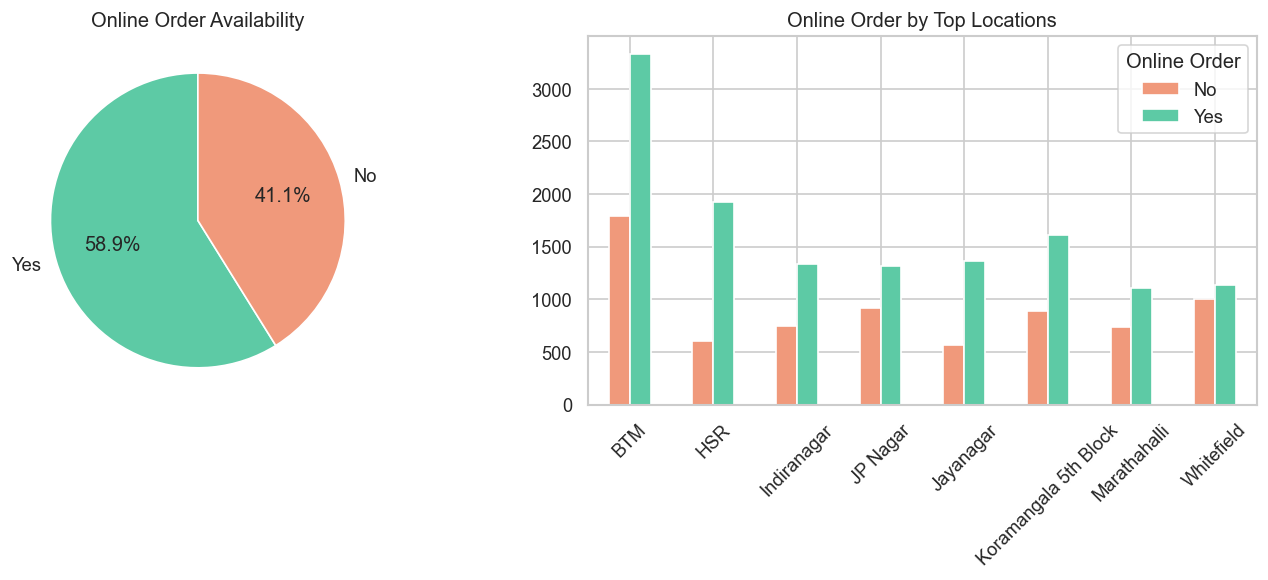

In [3]:
# Question: Do more restaurants offer online ordering or dine-in only?

counts = df['online_order'].value_counts()
# value_counts() counts how many Yes and No entries exist

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# subplots(1, 2) = 1 row, 2 charts side by side
# axes[0] = left chart, axes[1] = right chart

# Left: Pie chart
axes[0].pie(
    counts.values,            # the numbers
    labels=counts.index,      # "Yes" and "No"
    autopct='%1.1f%%',        # show percentage on each slice
    colors=['#5DCAA5', '#F0997B'],
    startangle=90
)
axes[0].set_title('Online Order Availability')

# Right: Count by location (top 8 only)
top_locs = df['location'].value_counts().head(8).index
df_top = df[df['location'].isin(top_locs)]

online_loc = df_top.groupby(['location', 'online_order']).size().unstack()
# groupby location AND online_order → count → unstack makes Yes/No columns
online_loc.plot(kind='bar', ax=axes[1], color=['#F0997B', '#5DCAA5'])
axes[1].set_title('Online Order by Top Locations')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Online Order')

plt.tight_layout()
plt.savefig('../visuals/charts/online_order_analysis.png')
plt.show()

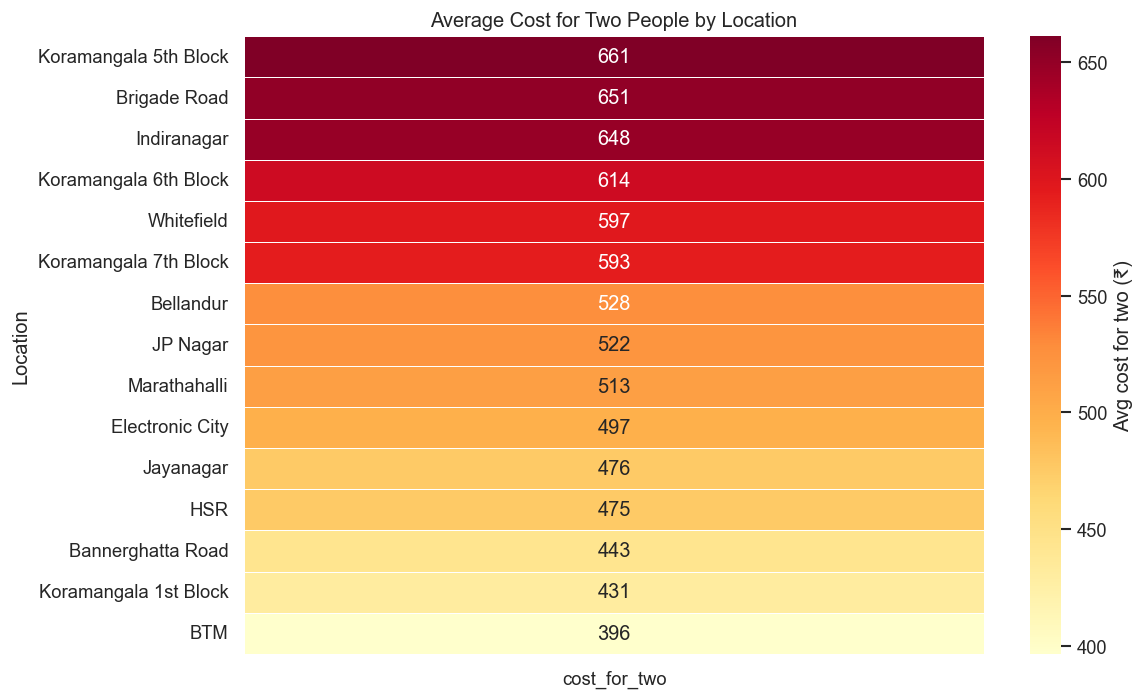

In [4]:
# Question: Which areas are most expensive? Which are budget-friendly?

# Get top 15 locations by restaurant count
top15 = df['location'].value_counts().head(15).index
df_top15 = df[df['location'].isin(top15)]

# Calculate average cost per location
avg_cost = df_top15.groupby('location')['cost_for_two'].mean().sort_values(ascending=False)
# groupby('location') → group rows by location
# ['cost_for_two'].mean() → average cost inside each group
# .sort_values() → sort highest to lowest

plt.figure(figsize=(10, 6))

# Reshape to a single-column dataframe for heatmap
heatmap_data = avg_cost.to_frame().T
# .to_frame() makes it a DataFrame, .T transposes rows↔columns

sns.heatmap(
    avg_cost.to_frame(),
    annot=True,          # show numbers inside each cell
    fmt='.0f',           # round to 0 decimal places
    cmap='YlOrRd',       # yellow → orange → red color scale
    linewidths=0.5,
    cbar_kws={'label': 'Avg cost for two (₹)'}
)
plt.title('Average Cost for Two People by Location')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('../visuals/charts/cost_heatmap.png')
plt.show()

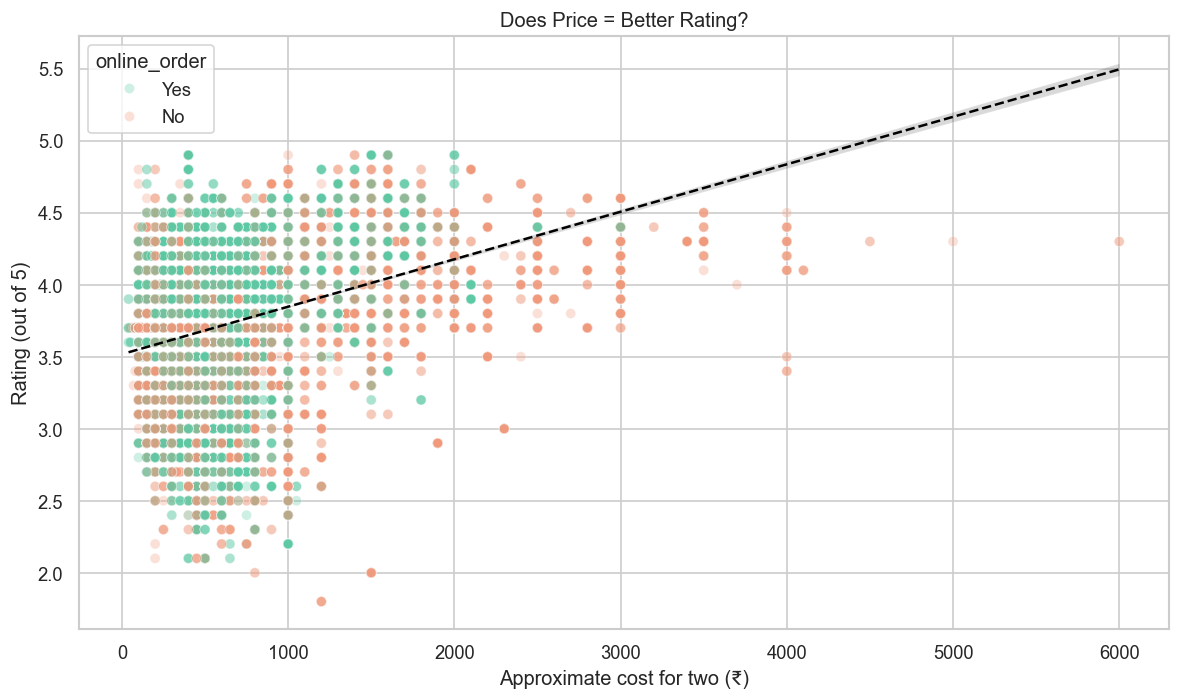

In [5]:
# Question: Do expensive restaurants actually get better ratings?

# Filter out extreme outliers (cost > ₹6000 are rare luxury places)
df_plot = df[df['cost_for_two'] <= 6000]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='cost_for_two',   # x axis = price
    y='rate',           # y axis = rating
    alpha=0.3,          # 30% opacity — helps when dots overlap
    hue='online_order', # color by online order availability
    palette={'Yes': '#5DCAA5', 'No': '#F0997B'}
)

# Add a trend line to see the overall pattern
sns.regplot(
    data=df_plot,
    x='cost_for_two',
    y='rate',
    scatter=False,      # don't draw dots again, just the line
    color='black',
    line_kws={'linewidth': 1.5, 'linestyle': '--'}
)

plt.title('Does Price = Better Rating?')
plt.xlabel('Approximate cost for two (₹)')
plt.ylabel('Rating (out of 5)')
plt.tight_layout()
plt.savefig('../visuals/charts/rating_vs_cost.png')
plt.show()

C:\Users\akki7\AppData\Local\Temp\ipykernel_38852\1909418973.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


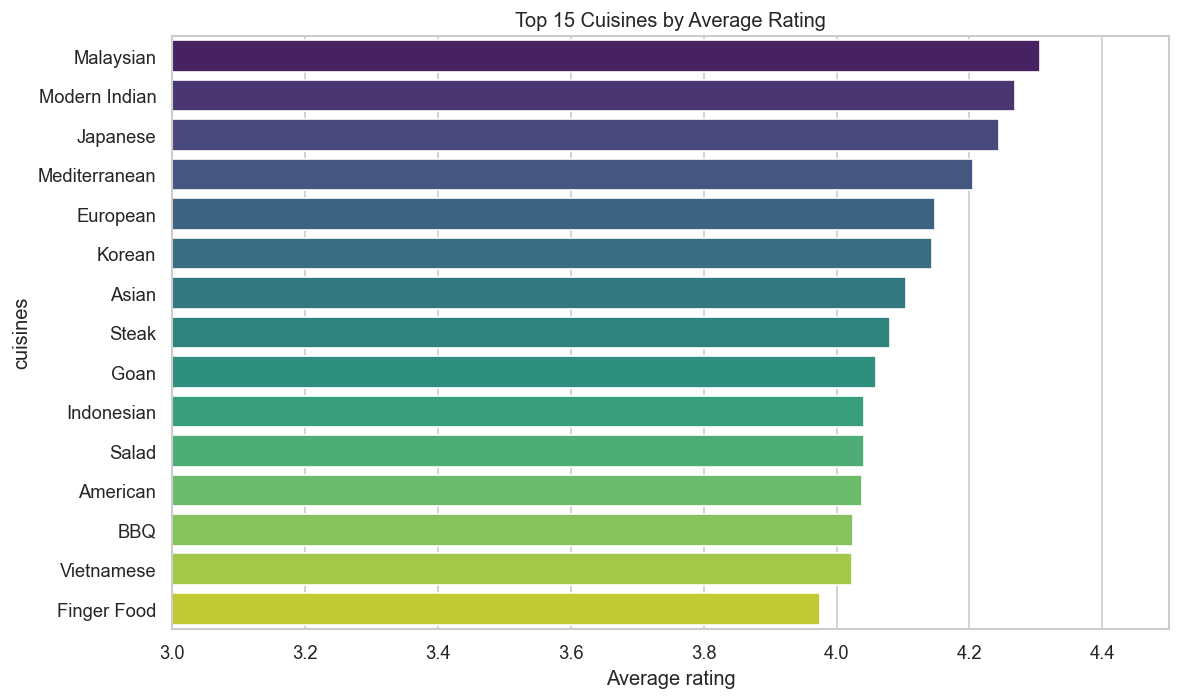

In [6]:
# Question: Which cuisine type gets the best ratings on average?

# Each restaurant can have multiple cuisines like "North Indian, Chinese"
# We need to split them into individual rows first
df_cuisine = df.copy()
df_cuisine['cuisines'] = df_cuisine['cuisines'].dropna()

# explode() splits "North Indian, Chinese" into 2 separate rows
df_exploded = df_cuisine.assign(
    cuisines=df_cuisine['cuisines'].str.split(', ')
).explode('cuisines')

# Average rating per cuisine, keep only those with 100+ restaurants
cuisine_rating = (
    df_exploded.groupby('cuisines')['rate']
    .agg(['mean', 'count'])          # calculate both average AND count
    .query('count >= 100')           # remove rare cuisines
    .sort_values('mean', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=cuisine_rating['mean'],
    y=cuisine_rating.index,
    palette='viridis'    # green to purple gradient palette
)
plt.title('Top 15 Cuisines by Average Rating')
plt.xlabel('Average rating')
plt.xlim(3.0, 4.5)      # zoom x axis — differences are subtle
plt.tight_layout()
plt.savefig('../visuals/charts/top_cuisines_rating.png')
plt.show()

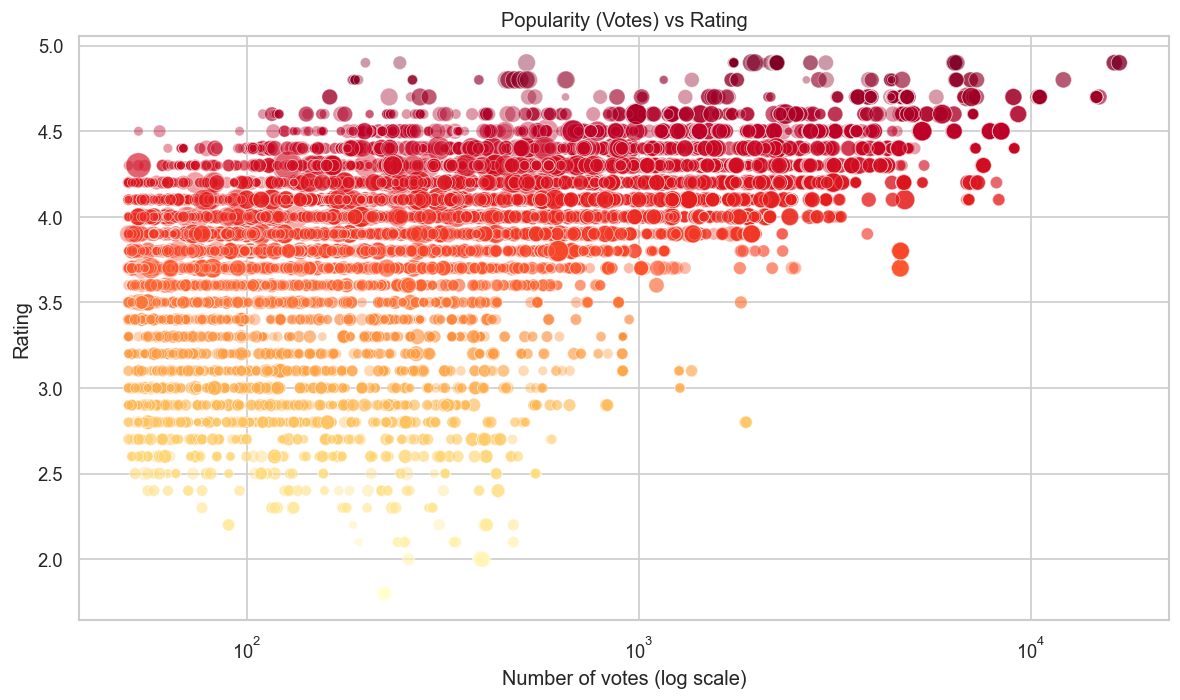

In [7]:
# Question: Are highly-rated restaurants also the most voted/popular?

# Filter to restaurants with at least 50 votes (ignore unknown places)
df_pop = df[df['votes'] >= 50]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_pop,
    x='votes',
    y='rate',
    alpha=0.4,
    size='cost_for_two',   # dot SIZE = price (bigger dot = pricier)
    sizes=(20, 300),       # min and max dot size in pixels
    hue='rate',
    palette='YlOrRd',
    legend=False
)

plt.xscale('log')   # log scale because votes range from 50 to 50,000
# log scale prevents a few hugely-voted restaurants from squashing all others
plt.title('Popularity (Votes) vs Rating')
plt.xlabel('Number of votes (log scale)')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('../visuals/charts/popularity_vs_rating.png')
plt.show()

In [8]:
# Print a clean summary of everything we discovered
print("=" * 50)
print("ZOMATO BANGALORE — KEY FINDINGS")
print("=" * 50)
print(f"Total restaurants analysed : {len(df):,}")
print(f"Average rating             : {df['rate'].mean():.2f} / 5")
print(f"Average cost for two       : ₹{df['cost_for_two'].median():.0f}")
print(f"Online ordering available  : {(df['online_order']=='Yes').mean()*100:.1f}%")
print(f"Unique locations           : {df['location'].nunique()}")
print(f"Unique cuisines            : {df['cuisines'].nunique()}")
print()
print("Top 3 locations by count:")
print(df['location'].value_counts().head(3).to_string())
print()
print("All 5 charts saved to visuals/charts/")

ZOMATO BANGALORE — KEY FINDINGS
Total restaurants analysed : 51,717
Average rating             : 3.70 / 5
Average cost for two       : ₹400
Online ordering available  : 58.9%
Unique locations           : 93
Unique cuisines            : 2723

Top 3 locations by count:
location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504

All 5 charts saved to visuals/charts/
